# Member 3 — Phase 2: Numerical EDA for Cancellation Risk

**Project:** Hotel Booking Demand — Cancellation Risk  
**Owner area:** Member 3 — Numerical EDA

This notebook explores numerical distributions, potential outliers, and numerical relationships with `is_canceled`. Each finding is framed as **Observation → Interpretation → Why it matters**. The analysis is descriptive/predictive and does not claim causation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../../data/raw/hotel_bookings.csv")
RESULTS_DIR = Path("../../results/eda")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
target = "is_canceled"
print("Shape:", df.shape)
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. Numerical feature scope

Some numeric-looking fields are identifiers, calendar codes, binary flags, or the target rather than continuous measures. They should not all be treated the same way in EDA.

In [2]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
identifier_like = ["agent", "company"]
calendar_codes = ["arrival_date_year", "arrival_date_week_number", "arrival_date_day_of_month"]
binary_flags = ["is_repeated_guest"]

analysis_numeric = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

print("All numeric columns:", numeric_columns)
print("\nMain numerical EDA columns:", analysis_numeric)
print("\nIdentifier-like numeric columns kept out of continuous analysis:", identifier_like)

All numeric columns: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Main numerical EDA columns: ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Identifier-like numeric columns kept out of continuous analysis: ['agent', 'company']


## 2. Descriptive summary

In [3]:
summary = df[analysis_numeric].describe().T
summary["missing"] = df[analysis_numeric].isna().sum()
summary

,count,mean,std,min,25%,50%,75%,max,missing
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0,0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0,0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0,0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0,0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0,4
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0,0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0,0
previous_bookings_not_canceled,119390.0,0.137097,1.497437,0.00,0.00,0.000,0.0,72.0,0
booking_changes,119390.0,0.221124,0.652306,0.00,0.00,0.000,0.0,21.0,0
days_in_waiting_list,119390.0,2.321149,17.594721,0.00,0.00,0.000,0.0,391.0,0


The summary shows strong skew/zero-inflation in several count variables and clear extremes in `lead_time`, `adr`, guest counts, and waiting-list days. These observations justify targeted outlier review, but an extreme value is not automatically an error.

## 3. Lead time and cancellation

Question: Do canceled and non-canceled bookings differ in how far in advance they were made?

In [4]:
lead_summary = df.groupby(target)["lead_time"].agg(["count", "mean", "median", "std"])
lead_summary.index = lead_summary.index.map({0: "Not canceled", 1: "Canceled"})
lead_summary

,count,mean,median,std
is_canceled,,,,
Not canceled,75166,79.984687,45.0,91.109888
Canceled,44224,144.848815,113.0,118.624829


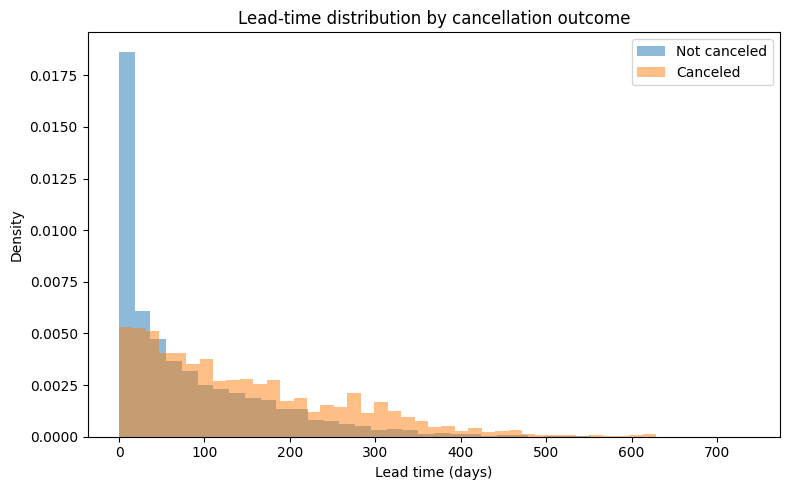

In [5]:
plt.figure(figsize=(8, 5))
for label, group in df.groupby(target):
    plt.hist(group["lead_time"], bins=40, alpha=0.5, density=True, label={0: "Not canceled", 1: "Canceled"}[label])
plt.title("Lead-time distribution by cancellation outcome")
plt.xlabel("Lead time (days)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "m3_lead_time_distribution.png", dpi=150)
plt.show()

In [6]:
lead_bins = [-1, 7, 30, 90, 180, 365, np.inf]
lead_labels = ["0–7", "8–30", "31–90", "91–180", "181–365", ">365"]
lead_group = pd.cut(df["lead_time"], bins=lead_bins, labels=lead_labels)
lead_rate = df.groupby(lead_group, observed=False)[target].agg(["count", "mean"])
lead_rate["cancellation_rate_pct"] = lead_rate["mean"] * 100
lead_rate

,count,mean,cancellation_rate_pct
lead_time,,,
0–7,19746,0.096323,9.632331
8–30,18960,0.278639,27.863924
31–90,29553,0.376984,37.698372
91–180,26439,0.447105,44.710466
181–365,21544,0.554540,55.453955
>365,3148,0.676620,67.662008


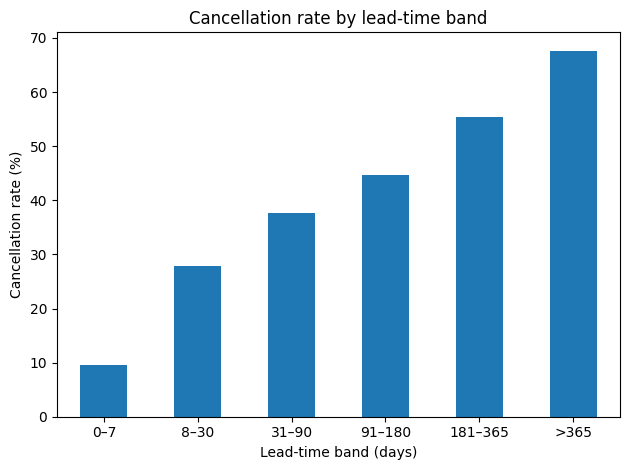

In [7]:
ax = lead_rate["cancellation_rate_pct"].plot(kind="bar")
ax.set_title("Cancellation rate by lead-time band")
ax.set_xlabel("Lead-time band (days)")
ax.set_ylabel("Cancellation rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "m3_lead_time_cancellation_rate.png", dpi=150)
plt.show()

**Observation → Interpretation → Why it matters**

- **Observation:** Canceled bookings have a median lead time of **113 days**, compared with **45 days** for non-canceled bookings. Cancellation rate rises from **9.63%** for bookings made 0–7 days ahead to **67.66%** for bookings made more than 365 days ahead.
- **Interpretation:** Longer booking horizons are strongly associated with cancellation in this historical dataset.
- **Why it matters:** `lead_time` is a promising predictor and should be retained unless a later leakage/availability audit finds a problem. The pattern is predictive, not proof that long lead time causes cancellation.

## 4. Numerical target comparison

Question: Which numerical fields show the clearest differences between canceled and non-canceled bookings?

In [8]:
target_compare = df.groupby(target)[analysis_numeric].agg(["mean", "median"]).T
target_compare.columns = ["not_canceled", "canceled"]
target_compare

not_canceled    canceled
lead_time                      mean       79.984687  144.848815
                               median     45.000000  113.000000
stays_in_weekend_nights        mean        0.928971    0.925267
                               median      1.000000    1.000000
stays_in_week_nights           mean        2.464053    2.561912
                               median      2.000000    2.000000
adults                         mean        1.829737    1.901728
                               median      2.000000    2.000000
children                       mean        0.102347    0.106513
                               median      0.000000    0.000000
babies                         mean        0.010377    0.003821
                               median      0.000000    0.000000
previous_cancellations         mean        0.015792    0.208348
                               median      0.000000    0.000000
previous_bookings_not_canceled mean        0.202977    0.025122
                               median      0.000000    0.000000
booking_changes                mean        0.293364    0.098340
                               median      0.000000    0.000000
days_in_waiting_list           mean        1.589868    3.564083
                               median      0.000000    0.000000
adr                            mean       99.987693  104.964333
                               median     92.500000   96.200000
required_car_parking_spaces    mean        0.099300    0.000000
                               median      0.000000    0.000000
total_of_special_requests      mean        0.714060    0.328826
                               median      1.000000    0.000000

Pearson correlation with is_canceled (descriptive only):
total_of_special_requests        -0.234658
required_car_parking_spaces      -0.195498
booking_changes                  -0.144381
previous_bookings_not_canceled   -0.057358
babies                           -0.032491
stays_in_weekend_nights          -0.001791
children                          0.005048
stays_in_week_nights              0.024765
adr                               0.047557
days_in_waiting_list              0.054186
adults                            0.060017
previous_cancellations            0.110133
lead_time                         0.293123
Name: is_canceled, dtype: float64


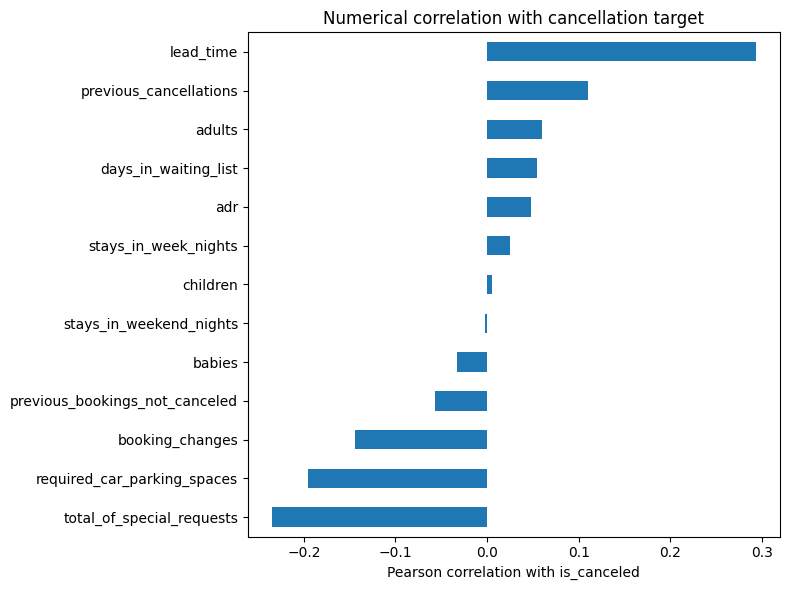

In [9]:
corr = (
    df[analysis_numeric + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values()
)
print("Pearson correlation with is_canceled (descriptive only):")
print(corr)

ax = corr.plot(kind="barh", figsize=(8, 6))
ax.set_title("Numerical correlation with cancellation target")
ax.set_xlabel("Pearson correlation with is_canceled")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "m3_numeric_target_correlations.png", dpi=150)
plt.show()

Correlation is only a screening view. Nonlinear and zero-inflated variables can be useful even when Pearson correlation is small. The strongest linear associations here include higher `lead_time` and `previous_cancellations`, and lower `total_of_special_requests`, `required_car_parking_spaces`, and `booking_changes`.

## 5. Special requests and cancellation

Question: Does the historical cancellation rate vary with the number of special requests?

In [10]:
special = df.groupby("total_of_special_requests")[target].agg(["count", "mean"])
special["cancellation_rate_pct"] = special["mean"] * 100
special

,count,mean,cancellation_rate_pct
total_of_special_requests,,,
0,70318,0.477204,47.720356
1,33226,0.220249,22.024920
2,12969,0.220989,22.098851
3,2497,0.178614,17.861434
4,340,0.105882,10.588235
5,40,0.050000,5.000000


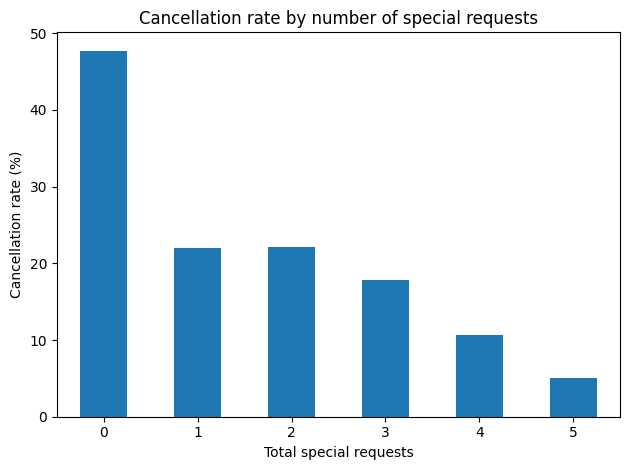

In [11]:
ax = special["cancellation_rate_pct"].plot(kind="bar")
ax.set_title("Cancellation rate by number of special requests")
ax.set_xlabel("Total special requests")
ax.set_ylabel("Cancellation rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "m3_special_requests_cancellation_rate.png", dpi=150)
plt.show()

**Observation → Interpretation → Why it matters**

- Bookings with **0 special requests** have a cancellation rate of about **47.72%**.
- The rate is about **22.02%** with 1 request, **22.10%** with 2, **17.86%** with 3, and **10.00%** for 4–5 requests combined.
- This is a strong historical association. The feature may help prediction, but it should not be interpreted as proof that making requests prevents cancellations.

## 6. Previous cancellations, booking changes, parking and waiting list

These variables are counts, so grouped cancellation rates are more interpretable than treating every value as continuous.

In [12]:
def grouped_rate(series, bins, labels):
    groups = pd.cut(series, bins=bins, labels=labels, include_lowest=True)
    out = df.groupby(groups, observed=False)[target].agg(["count", "mean"])
    out["cancellation_rate_pct"] = out["mean"] * 100
    return out

prev_cancel_rate = grouped_rate(
    df["previous_cancellations"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)
booking_change_rate = grouped_rate(
    df["booking_changes"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)
parking_rate = grouped_rate(
    df["required_car_parking_spaces"],
    bins=[-1, 0, np.inf],
    labels=["0", "1+"]
)
waiting_rate = grouped_rate(
    df["days_in_waiting_list"],
    bins=[-1, 0, 7, 30, np.inf],
    labels=["0", "1–7", "8–30", "31+"]
)

print("Previous cancellations:\n", prev_cancel_rate)
print("\nBooking changes:\n", booking_change_rate)
print("\nRequired parking spaces:\n", parking_rate)
print("\nDays in waiting list:\n", waiting_rate)

Previous cancellations:
                          count      mean  cancellation_rate_pct
previous_cancellations                                         
0                       112906  0.339061              33.906081
1                         6051  0.944307              94.430673
2                          116  0.327586              32.758621
3+                         317  0.599369              59.936909

Booking changes:
                   count      mean  cancellation_rate_pct
booking_changes                                         
0                101314  0.408542              40.854176
1                 12701  0.142272              14.227226
2                  3805  0.201314              20.131406
3+                 1570  0.165605              16.560510

Required parking spaces:
                               count      mean  cancellation_rate_pct
required_car_parking_spaces                                         
0                            111974  0.394949              39.494

**Observation → Interpretation → Why it matters**

- With **0 previous cancellations**, the cancellation rate is about **33.91%**; with **exactly 1 previous cancellation**, it is **94.43%**. Higher-count groups are not monotonic, so group size and context must be considered.
- Bookings with **0 booking changes** cancel at about **40.85%**, compared with **14.23%** when there is exactly 1 change.
- In this dataset, bookings requiring **at least one parking space have 0 observed cancellations**. This unusually strong pattern should be retained as an EDA finding but checked carefully in Phase 3 for feature availability, data-generation quirks, and generalizability.
- Waiting-list days show higher cancellation rates in several non-zero groups, but most bookings have zero waiting days, so this variable is highly zero-inflated.

These are associations, not causal effects.

## 7. ADR distribution and outlier review

Question: Are there strong cancellation differences in ADR, and are there values that need later treatment?

In [13]:
adr_by_target = df.groupby(target)["adr"].agg(["count", "mean", "median", "min", "max"])
adr_by_target.index = adr_by_target.index.map({0: "Not canceled", 1: "Canceled"})
print(adr_by_target)
print("\nADR quantiles:")
print(df["adr"].quantile([0, .01, .25, .50, .75, .99, .995, 1]))

              count        mean  median   min     max
is_canceled                                          
Not canceled  75166   99.987693    92.5 -6.38   510.0
Canceled      44224  104.964333    96.2  0.00  5400.0

ADR quantiles:
0.000      -6.380
0.010       0.000
0.250      69.290
0.500      94.575
0.750     126.000
0.990     252.000
0.995     275.000
1.000    5400.000
Name: adr, dtype: float64


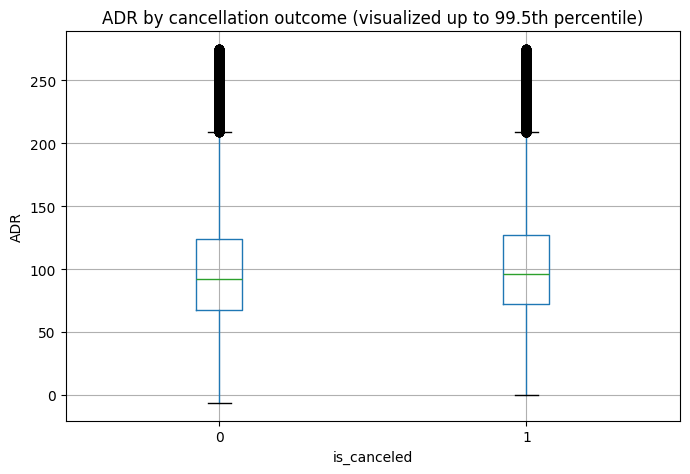

In [14]:
# Clip only for visualization so one extreme value does not flatten the box plot.
# The raw data is not changed.
upper_visual = df["adr"].quantile(0.995)
plot_df = df.loc[df["adr"] <= upper_visual, [target, "adr"]].copy()

fig, ax = plt.subplots(figsize=(7, 5))
plot_df.boxplot(column="adr", by=target, ax=ax)
ax.set_title("ADR by cancellation outcome (visualized up to 99.5th percentile)")
ax.set_xlabel("is_canceled")
ax.set_ylabel("ADR")
fig.suptitle("")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "m3_adr_boxplot.png", dpi=150)
plt.show()

**Observation → Interpretation → Why it matters**

Canceled bookings have a slightly higher ADR on average (**104.96**) than non-canceled bookings (**99.99**), but the linear correlation with the target is weak (about **0.048**). ADR also contains extreme values, including a maximum of **5,400** and one negative value. Phase 3 should investigate those records and compare robust treatment options rather than blindly removing all high values.

## 8. IQR outlier screen for selected continuous-like variables

IQR flags are diagnostic only. They are not automatic deletion rules, especially for skewed or count variables.

In [15]:
iqr_columns = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "days_in_waiting_list",
    "adr",
]

rows = []
for col in iqr_columns:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outliers = ((s < low) | (s > high)).sum()
    rows.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "lower_bound": low,
        "upper_bound": high,
        "iqr_flag_count": int(outliers),
        "iqr_flag_pct": outliers / len(s) * 100,
    })

pd.DataFrame(rows)

,feature,Q1,Q3,lower_bound,upper_bound,iqr_flag_count,iqr_flag_pct
0,lead_time,18.00,160.0,-195.000,373.000,3005,2.516961
1,stays_in_weekend_nights,0.00,2.0,-3.000,5.000,265,0.221962
2,stays_in_week_nights,1.00,3.0,-2.000,6.000,3354,2.809281
3,days_in_waiting_list,0.00,0.0,0.000,0.000,3698,3.097412
4,adr,69.29,126.0,-15.775,211.065,3793,3.176983


## Phase 2 handoff from Member 3

Strong numerical findings to add to the EDA insight log:

1. **Lead time** has a clear positive association with cancellation; median 113 days for canceled vs 45 for non-canceled bookings.
2. **Special requests** show a strong inverse association with cancellation.
3. **Previous cancellations** contain strong predictive signal, especially the exactly-one group, but the pattern is not monotonic across all counts.
4. **Booking changes** are associated with lower observed cancellation rates.
5. **Required car parking spaces** show an unusually strong historical separation (no cancellations when at least one space is required); this deserves formal feature-availability/generalizability review.
6. **ADR** differs only modestly by target and contains extreme values that need Phase 3 treatment decisions.
7. Several numerical variables are skewed or zero-inflated, so outlier handling must be feature-specific rather than automatic.

No rows or values were removed or transformed in the raw dataset during this EDA.